# Predicting Loan Default with LendingClub Data (2007-2018)
**PSTAT 100 Final Project - Spring Quarter, 2026**

Authors:

Nick Melo, Perm #: A0U9296

Lucas Ramirez, Perm #: A4P4X39

William Wallius, Perm #: A0R1R86 

Gurmaan Sohi, Perm #: A575J99

Karanbir Thind, Perm #: A0A6F35

In [62]:
from IPython.display import display, HTML
display(HTML("<style>pre { white-space: pre-wrap; }</style>")) #So code/comments don't get cut off

## Abstract

This project applies what we learned in PSTAT100, along with what we have learned throughout our time as undergraduates in data science, to a problem in consumer credit risk assessment. We use historical loan data from LendingClub Corporation, a peer-to-peer lending platform that connects borrowers with investors. Between 2007 and 2018, LendingClub originated over two million loans nationwide. Accurately predicting whether a borrower will default is a central problem in consumer finance, with implications for lending decisions, portfolio risk management, and financial regulation.

Our analysis proceeds through four phases. First, we loaded the LendingClub loan records (about 2.2 million in the full file). Because we did not need the entire dataset, we used the first 200 thousand rows (roughly 1/10th), which still gave us plenty of data to work with. This is not a random sample and skews toward older loans, which we note as a limitation. We then cleaned the data down to 26 borrower and loan-level features, restricting to loans with known outcomes (fully paid or charged off). Second, we conducted exploratory data analysis to understand how default rates vary across credit score bands, loan purposes, and home ownership categories. Third, we engineered a feature matrix by combining numeric predictors with one-hot encoded categorical variables and split the data into training and test sets. Finally, we fit an L2-regularized logistic regression model using a scikit-learn pipeline that standardizes features prior to estimation. We also went beyond the course scope and researched LightGBM, a gradient-boosted tree classifier, as an alternate model to compare against our logistic regression.

Our logistic regression model achieves an AUC-ROC of 0.7259 on a held-out test set, indicating meaningful discrimination between defaulting and non-defaulting loans. LightGBM achieved a modestly higher AUC of 0.7340. The most influential predictors in the logistic regression, based on standardized coefficients, include loan term, debt-to-income ratio, loan amount, and recent credit inquiries (increasing default risk), and FICO score, bank card credit limit, and annual income (decreasing default risk). These findings are broadly consistent with established credit risk literature. This report serves as a reproducible demonstration of the full data science workflow applied to a real-world financial classification problem.

## Introduction

### Background

Consumer credit risk is the probability that a borrower will fail to repay a debt obligation. Lenders, including banks, credit unions, and peer-to-peer platforms, must estimate/predict this exact probability for every loan application they receive. A credit risk model that is accurate not only helps lenders price loans appropriately, but also taps into subtopics such as: managing portfolio exposure, complying with regulatory requirements.

LendingClub Corporation, founded back in 2006 and eventually headquartered in San Francisco, was the world's largest peer-to-peer lending platform at its height. Rather than having to lend its own capital, LendingClub matched individuals looking to borrow loans with other individuals looking to invest. All of this was done in an online marketplace. Investors, having to take on the credit risk directly, led to LendingClub making detailed loan-level data public. Some of these variables included: borrower characteristics, loan terms, and final loan outcomes. The transparency available from this dataset, is a great factor in why we chose this data to research and investigate the drivers of default found in consumer lending.

The dataset used in this project covers accepted loan applications from 2007 through 2018 Q4 and contains over two million rows and approximately 150 columns.We restrict our analysis to a carefully chosen subset of 26 borrower and loan features that we believe were available at the time of loan origination, in order to approximate a realistic prediction setting. Some of these features may reflect a later snapshot of the credit file, which we note as a limitation.

### Project Aims

This project aims to:

1. Demonstrate the full data science lifecycle from raw data loading through model evaluation using a real-world financial dataset.
2. Build an interpretable logistic regression model that predicts loan default from borrower characteristics available at origination.
3. Identify the most influential predictors of default and relate them to domain knowledge in consumer credit.

### Report Structure

The remainder of this report is structured as follows. 

1. Methodology: Logistic Regression, L2 Regularization, Feature Standardization, Handling Class Imbalance, LightGBM, Model Evaluation, Model Fitting Procedure

2. Code Preparation: Required Packages

3. Data Subsetting

4. Data Cleaning: Binary target variable, Fix data types, Missing values

5. Data Analysis: FICO credit score vs. default rate, Default rate by loan purpose, Default rate by home ownership, Correlation heatmap of the numeric features

6. Engineering and Preprocessing

7. Regularized Logistic Regression: ROC Curve, Confusion Matrix, Top Predictive Features/Coefficients

8. LightGBM: Feature Importances, Model comparison/ROC Curve

9. Conclusions: Key Findings, EDA takeaways, Logistic regression, LightGBM (extended model), Limitations, Future Work

## 1. Methodology

### Logistic Regression

We picked logistic regression as the model to start with because it is very 
interpretable and we can see exactly which features are driving default risk 
just by looking at the coefficients. In a lending context, this matters because 
you need to be able to explain why a loan got flagged. Logistic regression has been a 
standard tool in consumer credit scoring for decades (Hand & Henley, 1997; 
Thomas, 2000).

The model estimates the probability of default given a borrower's features 
(Hastie et al., 2009, Ch. 4):

$$P(y_i = 1 \mid \mathbf{x}_i) = \sigma(\mathbf{x}_i^\top \boldsymbol{\beta}) 
= \frac{1}{1 + e^{-\mathbf{x}_i^\top \boldsymbol{\beta}}}$$

The coefficients are estimated by maximizing the log-likelihood 
(Hastie et al., 2009, Ch. 4):

$$\ell(\boldsymbol{\beta}) = \sum_{i=1}^{n} \left[ y_i \log 
\sigma(\mathbf{x}_i^\top \boldsymbol{\beta}) + (1 - y_i) \log(1 - 
\sigma(\mathbf{x}_i^\top \boldsymbol{\beta})) \right]$$

So a positive coefficient on dti (debt-to-income) means higher debt-to-income increases the 
predicted chance of default, and a negative coefficient on fico_avg means 
better credit scores lower it.

### L2 Regularization

After one-hot encoding the categorical variables we ended up with a lot of 
features, which can cause overfitting. L2 regularization fixes this by 
shrinking large coefficients toward zero (Hastie et al., 2009, Ch. 3):

$$\hat{\boldsymbol{\beta}} = \arg\max_{\boldsymbol{\beta}} \left[ 
\ell(\boldsymbol{\beta}) - \frac{1}{2C} \|\boldsymbol{\beta}\|_2^2 \right]$$

We implemented this using scikit-learn's LogisticRegression with penalty='l2' 
and C=1.0 (Pedregosa et al., 2011). We kept C=1.0 which is the sklearn
default. We tried a few values and this gave reasonable results so we 
left it there.

### Feature Standardization

Some features like annual_inc are in the hundreds of thousands while 
something like delinq_2yrs is usually just 0, 1, or 2. Without scaling, 
the regularization would unfairly shrink the income coefficient just 
because the numbers are bigger, not because it's less important 
(Hastie et al., 2009, Ch. 3).

We standardized everything to mean 0 and standard deviation 1 using 
scikit-learn's StandardScaler (Pedregosa et al., 2011):

$$\tilde{x}_{ij} = \frac{x_{ij} - \bar{x}_j}{s_j}$$

We fit the scaler on the training set only so nothing from the test set 
leaked into preprocessing.

### Handling Class Imbalance

Only about 20% of loans in our dataset defaulted. If we just trained the 
model normally it would learn to predict fully paid almost every time and 
still get 80% accuracy, which is not actually useful. Class imbalance is 
a well known challenge found in credit scoring (Thomas, 2000).

We used class_weight='balanced' in sklearn (Pedregosa et al., 2011), 
which automatically reweights each observation based on how common 
its class is:

$$w_i = \frac{n}{2 \cdot n_{y_i}}$$

By doing this, the model takes defaults more seriously during its training. The 
downside is it also produces more false positives, which you can see 
clearly in the confusion matrix.

### LightGBM

We also tried LightGBM as an extension since logistic regression can only 
capture linear relationships (Hastie et al., 2009, Ch. 10). We thought 
there might be interactions in the data like income times DTI that a 
linear model would miss. A high DTI is probably more dangerous for 
someone with low income than someone earning a lot.

LightGBM builds trees sequentially where each tree tries to fix the 
mistakes of the previous one (Ke et al., 2017):

$$P(y_i = 1 \mid \mathbf{x}_i) = \sigma\left(\sum_{k=1}^{K} 
f_k(\mathbf{x}_i)\right)$$

It also handles missing values natively and uses a leaf-wise growth 
strategy which makes it faster on larger datasets (Ke et al., 2017).

### Model Evaluation

We used two metrics to evaluate both models. AUC-ROC measures how well 
the model separates defaulters from non-defaulters across all thresholds, 
where 0.5 is random guessing and 1.0 is perfect (Hastie et al., 2009, 
Ch. 9). We also looked at the confusion matrix at the 0.5 threshold 
because AUC alone doesn't tell you about the actual tradeoff between 
missing defaults and flagging good borrowers, and those two errors have 
very different costs in a lending context (Hand & Henley, 1997).

### Model Fitting Procedure

1. Split 80/20 train/test with stratified sampling to keep the default 
   rate consistent across both splits (Pedregosa et al., 2011).
2. Fit the SimpleImputer (median) and StandardScaler on training data only, 
then apply to both sets.
3. Fit L2 logistic regression on the scaled training data.
4. Split 20% of the training data off as a validation set, then 
fit LightGBM on the remaining 80% with early stopping on validation 
AUC (Ke et al., 2017). The test set is not used for early stopping.
5. Evaluate both models on the held-out test set.

## 2. Code Preparation

### Required Packages

In [63]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore') #some warnings were popping up during modeling, added to keep output clean 

from sklearn.model_selection import train_test_split #To split the data into training and testing sets
from sklearn.linear_model import LogisticRegression #The logistic regression model for default prediction
from sklearn.preprocessing import StandardScaler #To standardize the features for better model performance
from sklearn.metrics import ( 
    roc_auc_score, roc_curve, classification_report, #Evaluate model performance using AUC-ROC, 
    ConfusionMatrixDisplay                           #Classification report, and confusion matrix
)
from sklearn.pipeline import Pipeline #Scaling and modeling
from sklearn.impute import SimpleImputer #To fill missing values using medians learned from the training data only
import lightgbm as lgb #Compare with logistic regression

plt.rcParams['figure.dpi'] = 150 #better resolution
sns.set_theme(style='whitegrid', palette='muted') 
RANDOM_STATE = 2026
print('Packages loaded.') 

Packages loaded.


## 3. Data Subsetting
We load only the columns we need for the project using the command `usecols` to avoid running out of memory on the full ~1.5 GB file.

In [64]:
features = [    #26 features plus the loan_status target, chosen from the 150+ columns of the raw dataset
    'loan_amnt', 'term',
    'annual_inc', 'dti',
    'fico_range_low', 'fico_range_high',
    'emp_length', 'home_ownership', 'verification_status',
    'purpose', 'addr_state',
    'open_acc', 'total_acc',
    'revol_bal', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec',
    'acc_now_delinq', 'pub_rec_bankruptcies',
    'total_bc_limit', 'bc_util', 'bc_open_to_buy',
    'avg_cur_bal', 'total_rev_hi_lim',
    'pct_tl_nvr_dlq', 'loan_status'
]

df_raw = pd.read_csv('accepted_2007_to_2018Q4.csv', usecols=features, low_memory=False, nrows=200000) 
print(f'Shape: {df_raw.shape}') 
df_raw.head(3) #To give an example of what the subset of the data looks like

Shape: (200000, 27)


,loan_amnt,term,emp_length,home_ownership,annual_inc,verification_status,loan_status,purpose,addr_state,dti,...,revol_util,total_acc,acc_now_delinq,total_rev_hi_lim,avg_cur_bal,bc_open_to_buy,bc_util,pct_tl_nvr_dlq,pub_rec_bankruptcies,total_bc_limit
0,3600.0,36 months,10+ years,MORTGAGE,55000.0,Not Verified,Fully Paid,debt_consolidation,PA,5.91,...,29.7,13.0,0.0,9300.0,20701.0,1506.0,37.2,76.9,0.0,2400.0
1,24700.0,36 months,10+ years,MORTGAGE,65000.0,Not Verified,Fully Paid,small_business,SD,16.06,...,19.2,38.0,0.0,111800.0,9733.0,57830.0,27.1,97.4,0.0,79300.0
2,20000.0,60 months,10+ years,MORTGAGE,63000.0,Not Verified,Fully Paid,home_improvement,IL,10.78,...,56.2,18.0,0.0,14000.0,31617.0,2737.0,55.9,100.0,0.0,6200.0


In [65]:
print(df_raw['loan_status'].value_counts()) #Loan status distribution

loan_status
Fully Paid            140992
Charged Off            35090
Current                22637
Late (31-120 days)       785
In Grace Period          347
Late (16-30 days)        148
Default                    1
Name: count, dtype: int64


## 4. Data Cleaning

We kept only `Fully Paid` and `Charged Off` / `Default` rows. Loans in the dataset listed that are `Current`, `Late`, or `In Grace Period` aren't completed, so we can't pull any conclusions from them.

In [66]:
completed_statuses = {'Fully Paid', 'Charged Off', 'Default'} #Analyzation focus
df = df_raw[df_raw['loan_status'].isin(completed_statuses)].copy() #Filter out incomplete loans
print(f'Rows after filtering out incomplete loans: {len(df):,}') 

Rows after filtering out incomplete loans: 176,083


### Binary target variable

Default rate: 0.1993


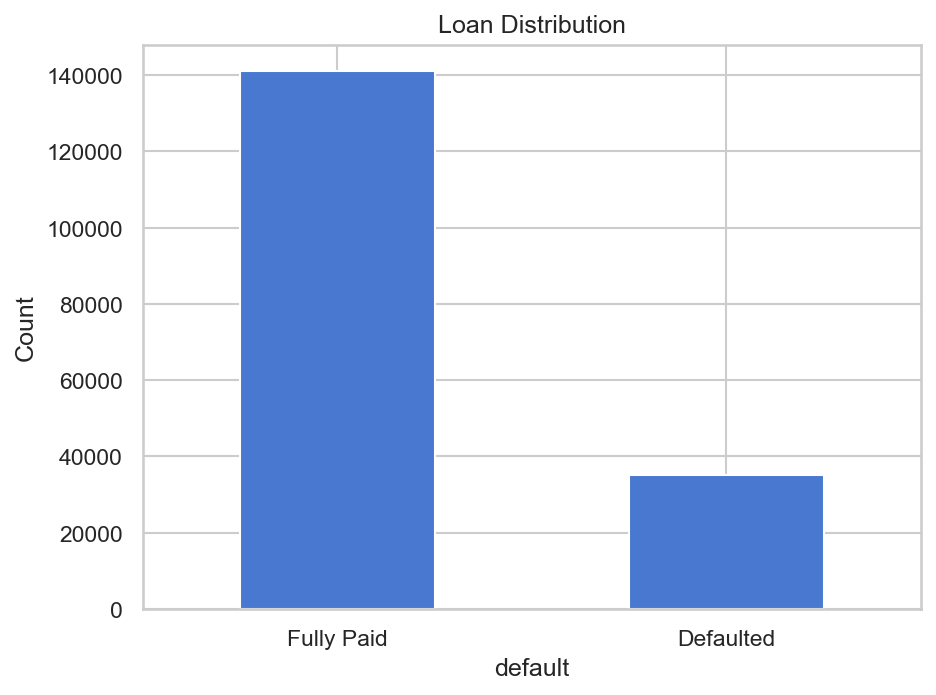

In [67]:
df['default'] = df['loan_status'].isin({'Charged Off', 'Default'}).astype(int) #Binary target variable
df.drop(columns='loan_status', inplace=True) #no longer need the original loan_status column
print('Default rate:', df['default'].mean().round(4)) #Overall default rate in the dataset

df['default'].value_counts().rename({0:'Fully Paid', 1:'Defaulted'}).plot( 
    kind='bar', title='Loan Distribution', rot=0
)
plt.ylabel('Count') 
plt.tight_layout()
plt.show()

### Fix data types

In [68]:
if df['revol_util'].dtype == object: 
    df['revol_util'] = df['revol_util'].str.replace('%', '', regex=False).astype(float) #Remove percentage sign and convert to float

df['term'] = df['term'].str.strip().str.extract(r'(\d+)').astype(float) #Extract numeric part of term and convert to float
df['emp_length'] = df['emp_length'].str.extract(r'(\d+)').astype(float) #Extract numeric part of emp_length and convert to float

print('Data types fixed.')
print(df.dtypes)

Data types fixed.
loan_amnt               float64
term                    float64
emp_length              float64
home_ownership              str
annual_inc              float64
verification_status         str
purpose                     str
addr_state                  str
dti                     float64
delinq_2yrs             float64
fico_range_low          float64
fico_range_high         float64
inq_last_6mths          float64
open_acc                float64
pub_rec                 float64
revol_bal               float64
revol_util              float64
total_acc               float64
acc_now_delinq          float64
total_rev_hi_lim        float64
avg_cur_bal             float64
bc_open_to_buy          float64
bc_util                 float64
pct_tl_nvr_dlq          float64
pub_rec_bankruptcies    float64
total_bc_limit          float64
default                   int64
dtype: object


### Missing values

In [69]:
missing = df.isnull().mean().sort_values(ascending=False) 
print('Missing fraction per column:') 
print(missing[missing > 0].round(3))

Missing fraction per column:
emp_length        0.063
bc_util           0.010
bc_open_to_buy    0.010
revol_util        0.000
dti               0.000
dtype: float64


In [70]:
high_missing = missing[missing > 0.4].index.tolist() #Identify columns with more than 40% missing values to drop
if high_missing:
    df.drop(columns=high_missing, inplace=True)
    print(f'Dropped high-missing columns: {high_missing}')

#numeric missing values are left as-is here and imputed inside the modeling pipeline to avoid leakage
cat_key = [c for c in ['home_ownership', 'purpose', 'verification_status'] if c in df.columns] #key cols to drop
df.dropna(subset=cat_key, inplace=True) #Drop remaining rows with missing values in key columns 
print(f'Final shape: {df.shape}')

Final shape: (176083, 27)


## 5. Data Analysis

### FICO credit score vs. default rate

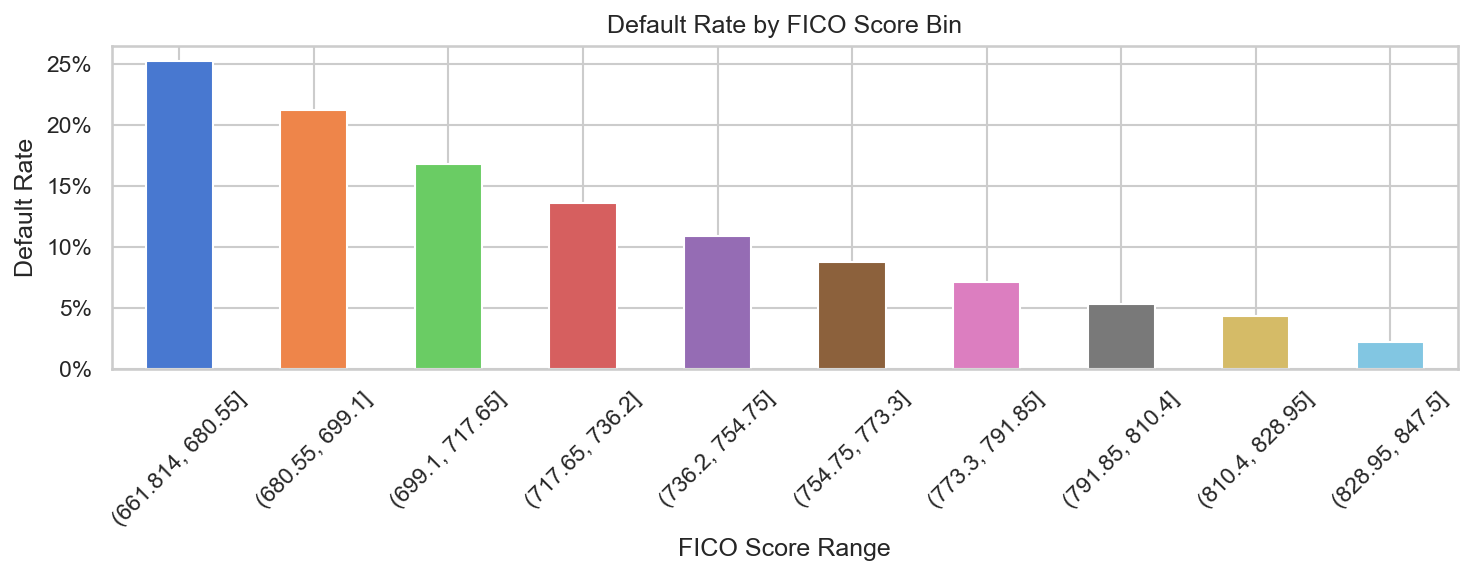

In [71]:
df['fico_avg'] = (df['fico_range_low'] + df['fico_range_high']) / 2 #average FICO score column for easier analysis

fico_bins = pd.cut(df['fico_avg'], bins=10) #10 bins for FICO score ranges
fico_default = df.groupby(fico_bins, observed=True)['default'].mean() #default rate for each bin

fig, ax = plt.subplots(figsize=(10, 4))
fico_default.plot(kind='bar', ax=ax, rot=45, color=sns.color_palette('muted', 10)) #Bar plot
ax.set_title('Default Rate by FICO Score Bin') 
ax.set_xlabel('FICO Score Range')
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) #Format y-axis as percentage
plt.tight_layout()
plt.show()

### Default rate by loan purpose

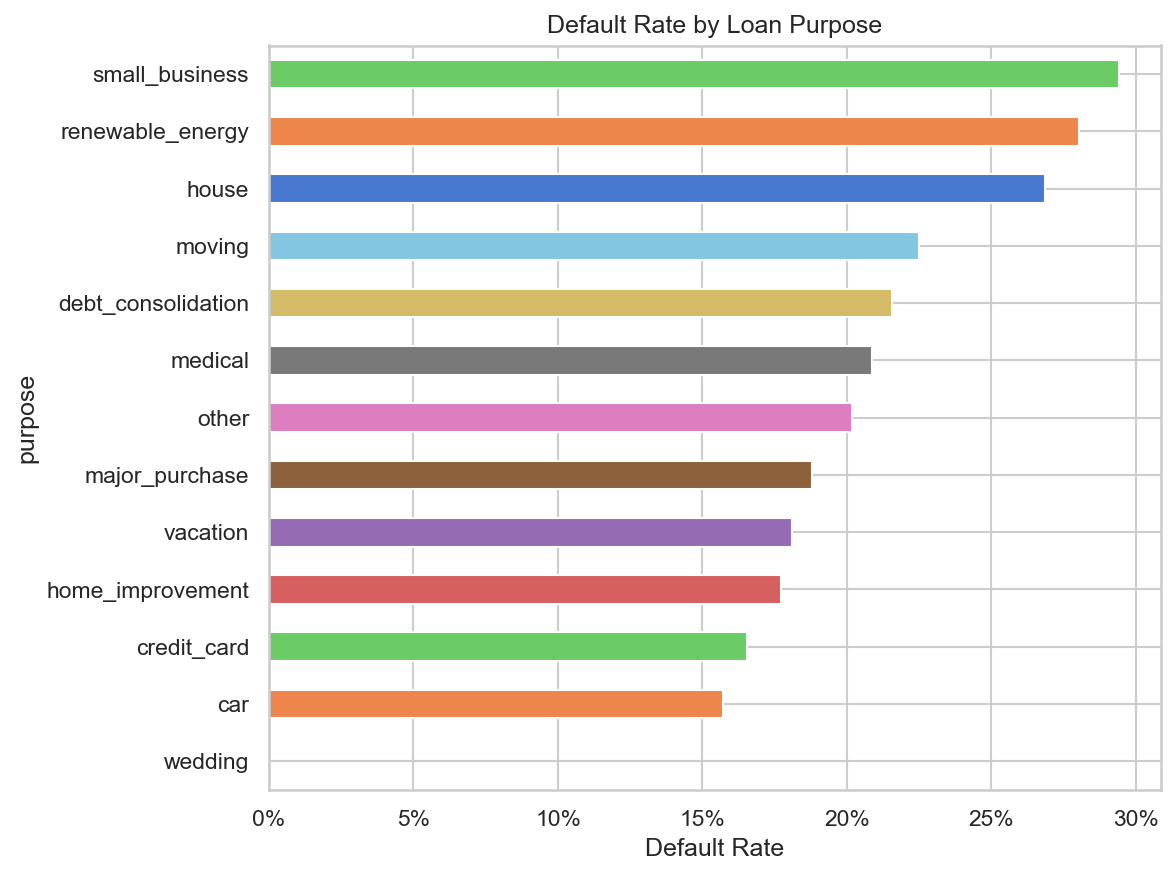

In [72]:
purpose_default = df.groupby('purpose')['default'].mean().sort_values() #default rate by loan purpose, sorted for better visualization

fig, ax = plt.subplots(figsize=(8, 6)) 
purpose_default.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(purpose_default))) #Horizontal bar plot
ax.set_title('Default Rate by Loan Purpose')
ax.set_xlabel('Default Rate') 
ax.xaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) #Format x-axis as percentage
plt.tight_layout()
plt.show()

### Default rate by home ownership 

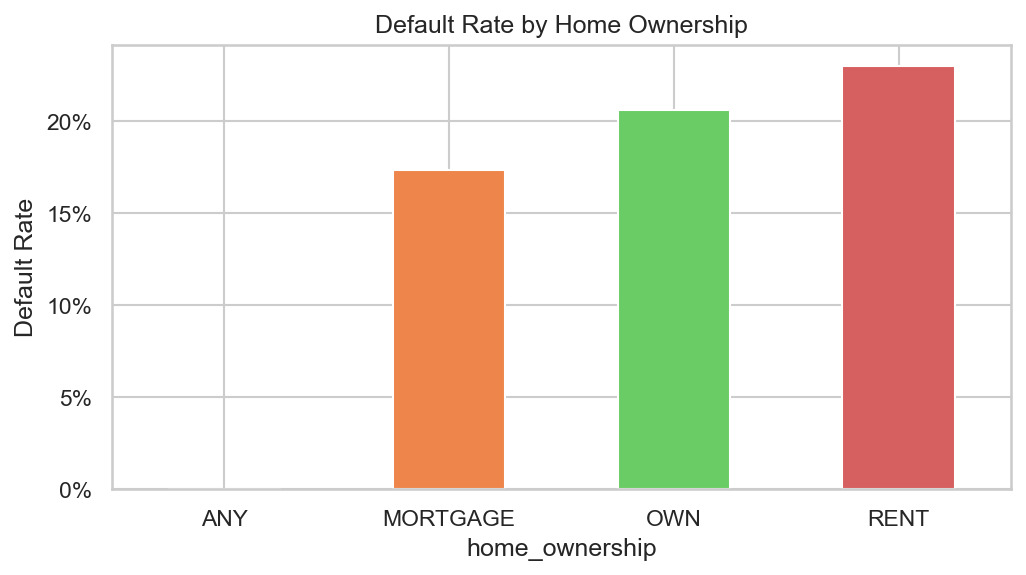

In [73]:
own_default = df.groupby('home_ownership')['default'].mean().sort_values()

fig, ax = plt.subplots(figsize=(7, 4))
own_default.plot(kind='bar', ax=ax, rot=0, color=sns.color_palette('muted', len(own_default))) #bar plot
ax.set_title('Default Rate by Home Ownership') 
ax.set_ylabel('Default Rate')
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda y, _: f'{y:.0%}')) #Formatted y-axis as percentage
plt.tight_layout()
plt.show()

### Correlation heatmap of the numeric features

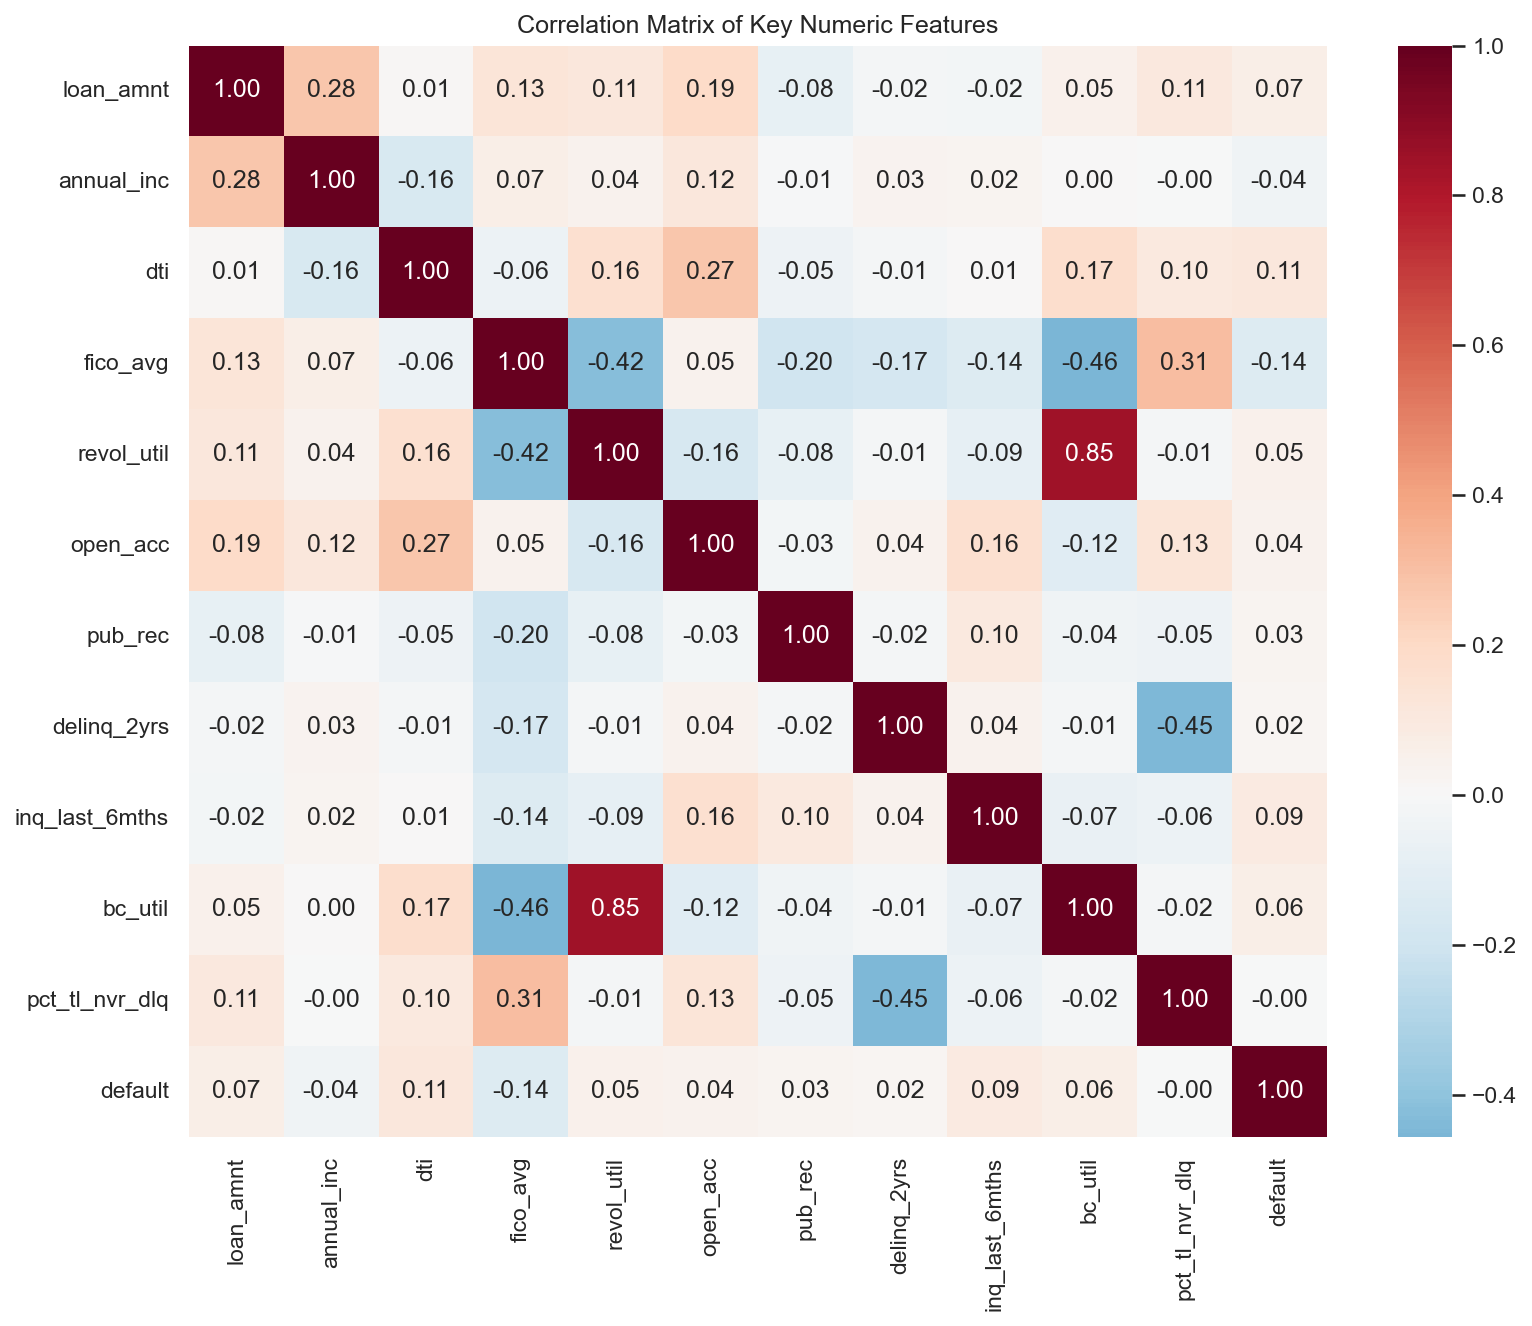

In [74]:
key_num = [#The key numeric features we chose to analyze for the correlation with default
    'loan_amnt', 'annual_inc', 'dti', 'fico_avg', 
    'revol_util', 'open_acc', 'pub_rec', 'delinq_2yrs',
    'inq_last_6mths', 'bc_util', 'pct_tl_nvr_dlq', 'default'
]
key_num = [c for c in key_num if c in df.columns] #to ensure all key numeric columns are present in the dataframe after dropping high-missing columns

fig, ax = plt.subplots(figsize=(11, 9))
sns.heatmap(df[key_num].corr(), annot=True, fmt='.2f', cmap='RdBu_r', center=0, ax=ax) #heatmap 
ax.set_title('Correlation Matrix of Key Numeric Features')
plt.tight_layout()
plt.show()

## 6. Engineering & Preprocessing

In [75]:
NUMERIC_FEATURES = [ #The numeric features we will use for the model
    'loan_amnt', 'term', 'annual_inc', 'dti',
    'fico_avg', 'emp_length',
    'open_acc', 'total_acc', 'revol_bal', 'revol_util',
    'inq_last_6mths', 'delinq_2yrs', 'pub_rec',
    'acc_now_delinq', 'pub_rec_bankruptcies',
    'total_bc_limit', 'bc_util', 'bc_open_to_buy',
    'avg_cur_bal', 'total_rev_hi_lim', 'pct_tl_nvr_dlq'
]
CATEGORICAL_FEATURES = [ #The categorical features we will use for the model
    'home_ownership', 'verification_status', 'purpose', 'addr_state'
]

NUMERIC_FEATURES     = [c for c in NUMERIC_FEATURES     if c in df.columns] #numeric cols present after dropping high-missing columns
CATEGORICAL_FEATURES = [c for c in CATEGORICAL_FEATURES if c in df.columns] #categorical cols present after dropping high-missing columns

print('Numeric features:',     NUMERIC_FEATURES) 
print('Categorical features:', CATEGORICAL_FEATURES)

Numeric features: ['loan_amnt', 'term', 'annual_inc', 'dti', 'fico_avg', 'emp_length', 'open_acc', 'total_acc', 'revol_bal', 'revol_util', 'inq_last_6mths', 'delinq_2yrs', 'pub_rec', 'acc_now_delinq', 'pub_rec_bankruptcies', 'total_bc_limit', 'bc_util', 'bc_open_to_buy', 'avg_cur_bal', 'total_rev_hi_lim', 'pct_tl_nvr_dlq']
Categorical features: ['home_ownership', 'verification_status', 'purpose', 'addr_state']


In [76]:
df_model = pd.get_dummies( #One-hot encode categorical features and combine with numeric features and target variable for modeling
    df[NUMERIC_FEATURES + CATEGORICAL_FEATURES + ['default']],
    columns=CATEGORICAL_FEATURES,
    drop_first=True
)

X = df_model.drop(columns='default')
y = df_model['default']#Feature matrix and target variable for modeling

print(f'Feature matrix shape: {X.shape}') 
print(f'Default rate: {y.mean():.3f}')

Feature matrix shape: (176083, 86)
Default rate: 0.199


In [77]:
X_train, X_test, y_train, y_test = train_test_split( #Split the data into training and testing sets to maintain default distribution
    X, y, test_size=0.2, random_state=RANDOM_STATE, stratify=y #stratify to maintain the same default distribution in train and test sets
)
print(f'Train size: {len(X_train):,} | Test size: {len(X_test):,}') 

Train size: 140,866 | Test size: 35,217


## 7. Regularized Logistic Regression

We use L2-regularized logistic regression to model the probability of default. `class_weight='balanced'` upweights the minority (default) class to account for class imbalance. Features are standardized since logistic regression is sensitive to scale.

In [78]:
log_reg_pipe = Pipeline([ #Imputation, scaling, and logistic regression with L2 regularization and balanced class weights
    ('imputer', SimpleImputer(strategy='median')), #fill missing numeric values with training-set medians
    ('scaler', StandardScaler()),
    ('clf', LogisticRegression(
        penalty='l2', #L2 regularization to prevent overfitting
        C=1.0, #for smaller values to increase regularization strength, for larger values to decrease regularization strength
        class_weight='balanced', #balanced class weights to handle class imbalance
        max_iter=500, 
        random_state=RANDOM_STATE, #reproducibility
        solver='lbfgs' #optimize 
    ))
])

log_reg_pipe.fit(X_train, y_train)
print('Logistic regression trained.')

Logistic regression trained.


In [79]:
y_prob = log_reg_pipe.predict_proba(X_test)[:, 1] #positive class probabilities
y_pred = log_reg_pipe.predict(X_test) #predicted class 

auc = roc_auc_score(y_test, y_prob) #AUC ROC score
print(f'AUC-ROC: {auc:.4f}') #to evaluate model ability
print()
print(classification_report(y_test, y_pred, target_names=['Fully Paid', 'Defaulted']))

AUC-ROC: 0.7259

              precision    recall  f1-score   support

  Fully Paid       0.88      0.68      0.77     28199
   Defaulted       0.34      0.64      0.44      7018

    accuracy                           0.67     35217
   macro avg       0.61      0.66      0.61     35217
weighted avg       0.78      0.67      0.70     35217



### ROC Curve

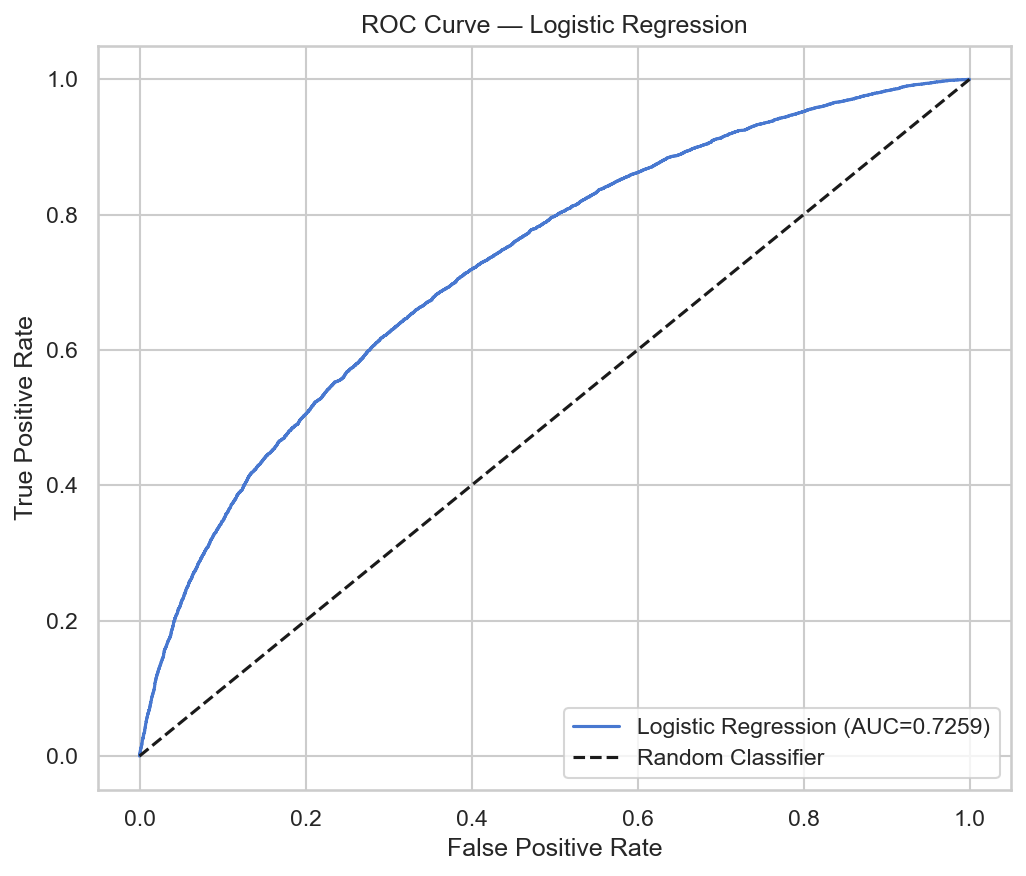

In [80]:
fpr, tpr, _ = roc_curve(y_test, y_prob) #False positive rate, true positive rate, and thresholds for ROC curve

fig, ax = plt.subplots(figsize=(7, 6))#ROC curve
ax.plot(fpr, tpr, label=f'Logistic Regression (AUC={auc:.4f})') #plot for roc curve with 
ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve — Logistic Regression')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

### Confusion matrix

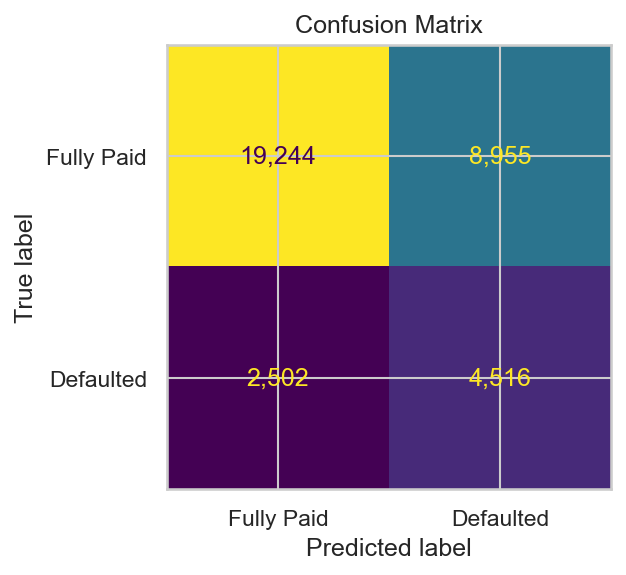

In [81]:
fig, ax = plt.subplots(figsize=(5, 4)) #Confusion matrix for logistic regression
disp = ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred,
    display_labels=['Fully Paid', 'Defaulted'],
    ax=ax, colorbar=False,
    values_format=',d' #show full counts with commas instead of scientific notation
)
ax.set_title('Confusion Matrix')
plt.tight_layout()
plt.show()

### Top predictive features/coefficients

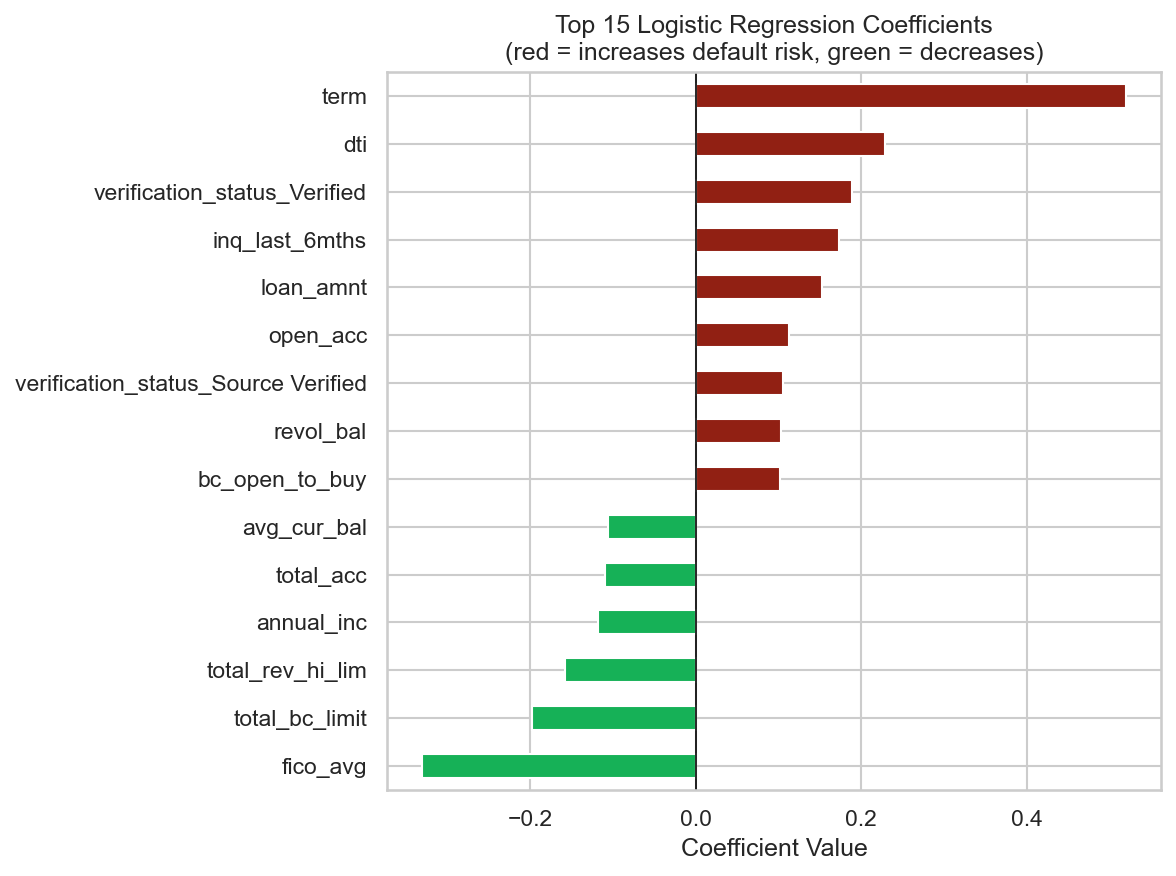

In [82]:
coefs = pd.Series( 
    log_reg_pipe.named_steps['clf'].coef_[0], #Extract the coefficients from the logistic regression model 
    index=X.columns
).sort_values(key=abs, ascending=False)

top_n = 15
top_coefs = coefs.head(top_n).sort_values() #Get the top 15 coefficients by absolute value and sort them for better visualization

colors = ["#912013" if v > 0 else "#16b157" for v in top_coefs] #red for increased risk, green for decreased risk
fig, ax = plt.subplots(figsize=(8, 6))
top_coefs.plot(kind='barh', ax=ax, color=colors)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title(f'Top {top_n} Logistic Regression Coefficients\n(red = increases default risk, green = decreases)')
ax.set_xlabel('Coefficient Value')
plt.tight_layout()
plt.show()

## 8. LightGBM (Extended Model)

LightGBM is a gradient-boosted decision tree algorithm, that builds trees sequentially. This allows it to correct the errors of the previous, and is well established for credit data due to its ability to capture non-linear feature interactions that logistic regression cannot.

This section is part of our research we did beyond what the course material covered. 

In [83]:
X_tr, X_val, y_tr, y_val = train_test_split( #carve a validation set out of the training data for early stopping
    X_train, y_train, test_size=0.2,
    random_state=RANDOM_STATE, stratify=y_train #stratify to keep the same default rate in both pieces
)
print(f'LightGBM train size: {len(X_tr):,} | Validation size: {len(X_val):,}')

LightGBM train size: 112,692 | Validation size: 28,174


In [84]:
neg_pos_ratio = (y_tr == 0).sum() / (y_tr == 1).sum() #ratio of neg to pos samples in the LightGBM training set

lgb_model = lgb.LGBMClassifier( #LightGBM model with scale_pos_weight to handle class imbalance
    n_estimators=2000, #high ceiling on boosting rounds, early stopping picks the actual number
    learning_rate=0.03, #lower learning rate so the model improves gradually instead of stopping after a few trees
    num_leaves=31, #Maximum number of leaves in one tree, smaller than before to reduce overfitting
    max_depth=-1, #no limit on tree depth
    min_child_samples=100, #Minimum number of data points in a leaf to prevent overfitting
    subsample=0.8, #Subsample ratio of the training instances to prevent overfitting
    subsample_freq=1, #required for subsample to take effect, otherwise LightGBM ignores it
    colsample_bytree=0.8, #Subsample ratio of columns when constructing each tree to prevent overfitting
    reg_lambda=5.0, #L2 regularization on the leaf weights to prevent overfitting
    scale_pos_weight=neg_pos_ratio, #Handles the class imbalance by weighting the positive class more heavily
    random_state=RANDOM_STATE, #reproducibility
    n_jobs=-1, #to use full CPU for faster training
    verbose=-1 #don't print training messages
)

lgb_model.fit( #Train the LightGBM model with early stopping based on AUC-ROC on the validation set
    X_tr, y_tr, #the training portion of the training data
    eval_set=[(X_val, y_val)], #evaluate on the validation set (not the test set) for early stopping
    eval_metric='auc', #stop based on AUC rather than logloss, which is distorted by scale_pos_weight
    callbacks=[lgb.early_stopping(100, first_metric_only=True, verbose=False), lgb.log_evaluation(period=0)] #stop based only on the first metric (AUC), ignore logloss
)
print(f'Best iteration: {lgb_model.best_iteration_}')
print(lgb_model.evals_result_['valid_0'].keys())

Best iteration: 606
odict_keys(['auc', 'binary_logloss'])


In [85]:
y_prob_lgb = lgb_model.predict_proba(X_test)[:, 1] #positive class probabilities from the LightGBM model
y_pred_lgb = lgb_model.predict(X_test) #predicted class from the LightGBM model 

auc_lgb = roc_auc_score(y_test, y_prob_lgb) #AUC-ROC score for the LightGBM model
print(f'LightGBM AUC-ROC: {auc_lgb:.4f}') 
print()
print(classification_report(y_test, y_pred_lgb, target_names=['Fully Paid', 'Defaulted']))

LightGBM AUC-ROC: 0.7340

              precision    recall  f1-score   support

  Fully Paid       0.89      0.69      0.78     28199
   Defaulted       0.34      0.64      0.45      7018

    accuracy                           0.68     35217
   macro avg       0.61      0.67      0.61     35217
weighted avg       0.78      0.68      0.71     35217



### LightGBM feature importances

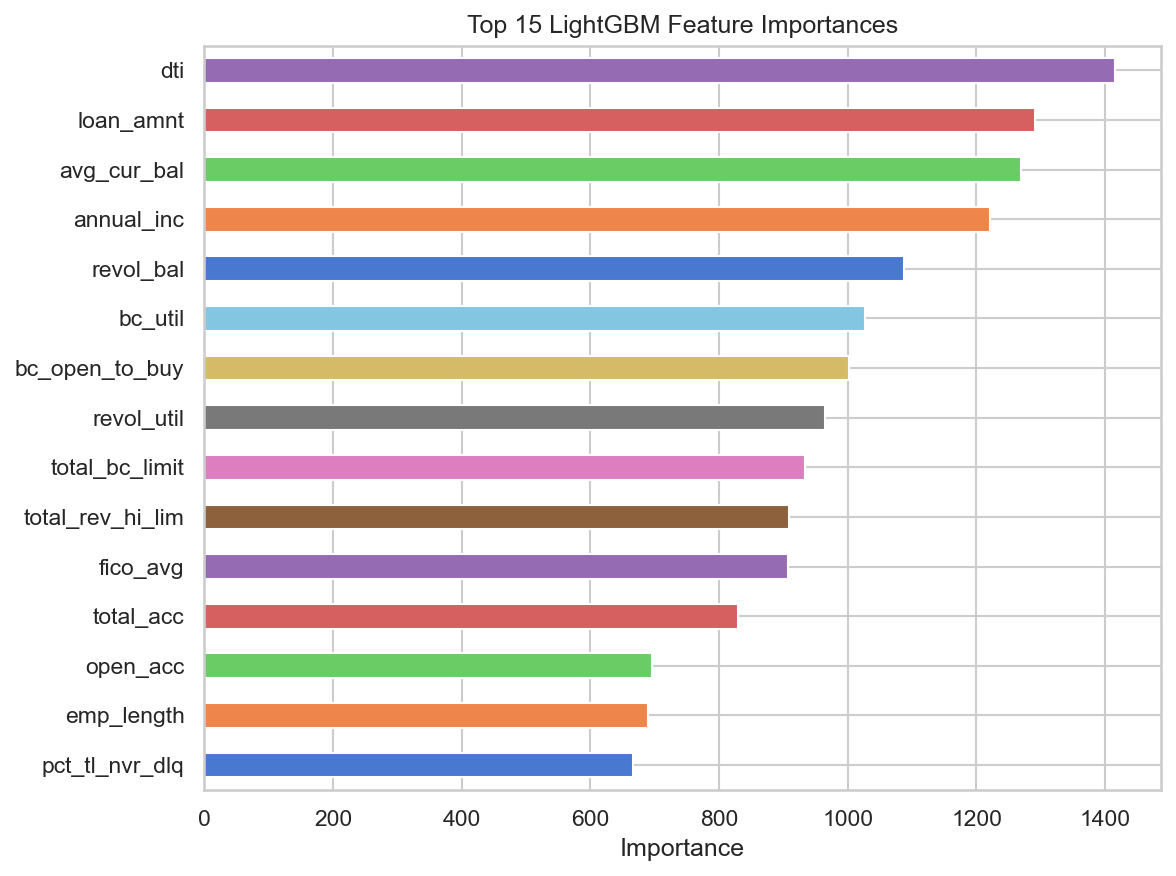

In [86]:
importances = pd.Series( #Series for top 15 feature importances from the LightGBM model
    lgb_model.feature_importances_,
    index=X.columns
).sort_values(ascending=False).head(15).sort_values()

fig, ax = plt.subplots(figsize=(8, 6))#Bar plot for the above
importances.plot(kind='barh', ax=ax, color=sns.color_palette('muted', len(importances)))
ax.set_title('Top 15 LightGBM Feature Importances')
ax.set_xlabel('Importance')
plt.tight_layout()
plt.show()

### Model comparison, ROC curves

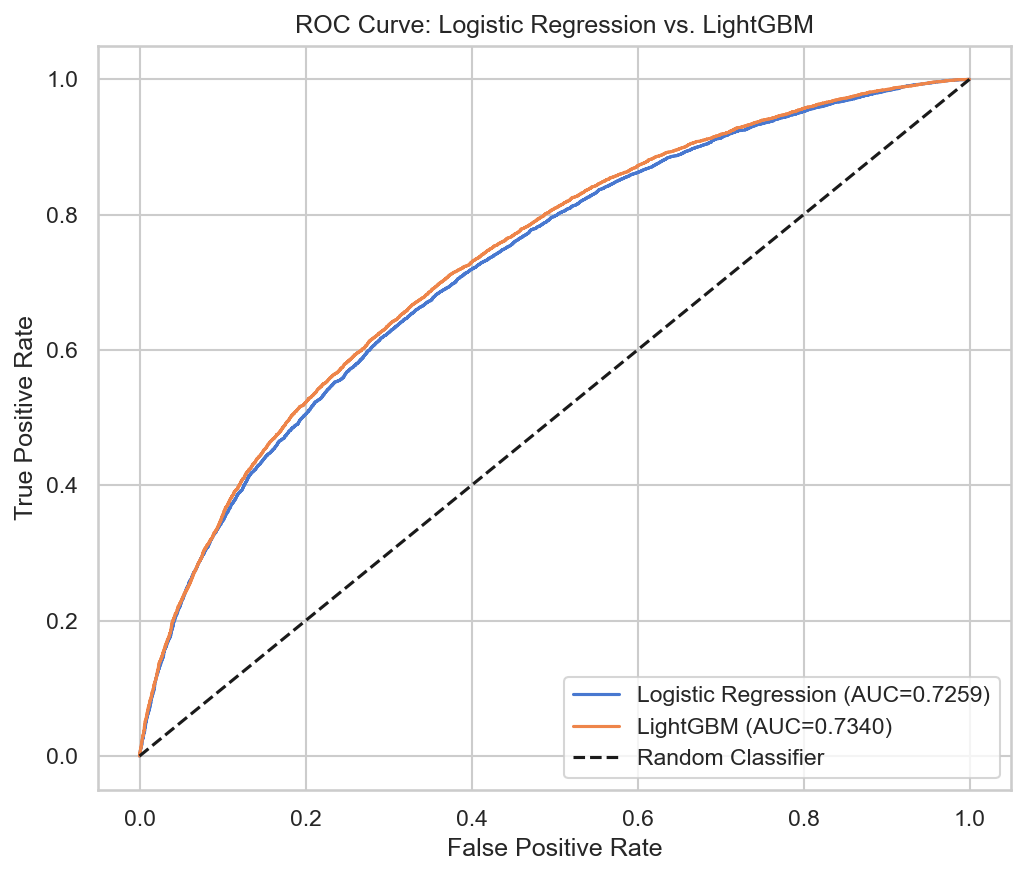

                   Model  AUC-ROC
Logistic Regression (L2)   0.7259
                LightGBM   0.7340


In [87]:
auc_lr = roc_auc_score(y_test, y_prob) #AUC score for logistic regression model

fig, ax = plt.subplots(figsize=(7, 6)) #ROC curve

for probs, label, auc in [
    (y_prob,     f'Logistic Regression (AUC={auc_lr:.4f})', auc_lr), #probabilities, label, and AUC for logistic regression
    (y_prob_lgb, f'LightGBM (AUC={auc_lgb:.4f})',          auc_lgb),
]:
    fpr, tpr, _ = roc_curve(y_test, probs) #false, true, thresholds for curve
    ax.plot(fpr, tpr, label=label)

ax.plot([0, 1], [0, 1], 'k--', label='Random Classifier') #reference line for random classifier
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_title('ROC Curve: Logistic Regression vs. LightGBM')
ax.legend(loc='lower right')
plt.tight_layout()
plt.show()

summary = pd.DataFrame({
    'Model': ['Logistic Regression (L2)', 'LightGBM'],
    'AUC-ROC': [round(auc_lr, 4), round(auc_lgb, 4)],
})
print(summary.to_string(index=False))

## 9. Conclusions

### Key Findings

**EDA:**
- FICO score was one of the strongest predictors we found, with lower 
FICO borrowers defaulting at much higher rates across every bin we looked at.
- Small business loans had the highest default rate by purpose at around 29%.
- Renters defaulted more often than borrowers who owned their home or 
  had a mortgage.

**Logistic Regression:**
- Our L2 logistic regression with class_weight='balanced' handled the 
  class imbalance reasonably well and got an AUC of 0.7259
- The biggest risk-increasing predictors were term, dti, loan_amnt, 
  and inq_last_6mths.
- The most protective features were fico_avg, total_bc_limit, and 
  annual_inc.

**LightGBM:**
- After fixing early stopping (using a validation split from the training 
data instead of the test set), LightGBM achieved an AUC of 0.7340 compared to 
0.7259 for logistic regression, a modest improvement of about 0.008.
- At the 0.5 threshold, LightGBM's precision and recall on defaults (0.34 / 0.64) 
were essentially identical to logistic regression's (0.34 / 0.64), so the practical 
gain is small.
- The small lift suggests that most of the predictive signal in these features is 
roughly linear, and that non-linear interactions like income times DTI add only 
a little in this dataset.

### Limitations
- Logistic regression can only find linear patterns. LightGBM captured some 
non-linear structure and improved AUC slightly, but we only used a single 
train/test split, so the performance numbers (and a difference of 0.008 between models) 
could shift depending on how the data is divided.
- addr_state and purpose could be acting as proxies for demographic groups, which would 
be a problem in a real deployment.
- We loaded the first 200,000 rows of the file with `nrows`, which is ordered by date, 
so the sample is not random and skews toward older loans. Results might differ on the 
full 2.2 million rows.
- Some features (such as bc_util, avg_cur_bal, and pct_tl_nvr_dlq) may reflect 
a later snapshot of the borrower's credit file rather than the application date, 
so our assumption that every feature was known at origination may not fully hold.

### Future Work
- SMOTE or undersampling to address the class imbalance beyond what 
  class_weight='balanced' is already doing.
- A fairness audit on sensitive features like addr_state and purpose 
  which could be acting as proxies for demographic groups.
- Hyperparameter tuning via cross-validated search for LightGBM, and 
cross-validated AUC for both models to check whether the gap between them 
is meaningful.

## References

1. LendingClub Corporation. *LendingClub Historical Loan Data (2007-2018)*. Available at: https://www.kaggle.com/datasets/wordsforthewise/lending-club

2. Hastie, T., Tibshirani, R., & Friedman, J. (2009). *The Elements of Statistical Learning: Data Mining, Inference, and Prediction* (2nd ed.). Springer. https://doi.org/10.1007/978-0-387-84858-7

3. Ke, G., Meng, Q., Finley, T., Wang, T., Chen, W., Ma, W., Ye, Q., & Liu, T.-Y. (2017). LightGBM: A Highly Efficient Gradient Boosting Decision Tree. *Advances in Neural Information Processing Systems*, 30. https://papers.nips.cc/paper/2017/hash/6449f44a102fde848669bdd9eb6b76fa-Abstract.html

4. Pedregosa, F., et al. (2011). Scikit-learn: Machine Learning in Python. *Journal of Machine Learning Research*, 12, 2825-2830. http://jmlr.org/papers/v12/pedregosa11a.html

5. Thomas, L. C. (2000). A survey of credit and behavioural scoring: Forecasting financial risk of lending to consumers. *International Journal of Forecasting*, 16(2), 149-172. https://doi.org/10.1016/S0169-2070(00)00034-0

6. Hand, D. J., & Henley, W. E. (1997). Statistical Classification Methods in Consumer Credit Scoring: A Review. *Journal of the Royal Statistical Society: Series A*, 160(3), 523-541. https://doi.org/10.1111/j.1467-985X.1997.00078.x